<a href="https://colab.research.google.com/github/aymuos/endgame/blob/main/07_reward_oracle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Notebook Snapshot: Reward Oracle for Bandits Simulator

**1. Objective:**
Developed a city-specific reward oracle (delivery duration predictor) for a multi-armed bandit simulator using the LaDe dataset. The goal was to predict 'pre-action' incremental delivery duration.

**2. Data Processing & Feature Engineering:**
*   **Cities:** Chongqing, Shanghai, and Hangzhou.
*   **Static Features:** 27 features (e.g., distance, weather, structural batch info).
*   **Dynamic Features:** Engineered 7 'pre-action' states including `batch_progress`, `elapsed_route_time`, and `dist_from_current`.
*   **Cyclic Encoding:** Applied sin/cos transformations to temporal features to capture diurnal patterns.
*   **Leakage Prevention:** Implemented a batch-wise split (70/10/20) ensuring no training data leakage into validation/test sets.

**3. Modeling Strategy:**
*   **Algorithm:** LightGBM (GBDT) for regression.
*   **Baseline:** Compared against a 'Mean Target' baseline.
*   **Feature Selection Comparison:**
    *   **Full-Features (35):** All static + dynamic features.
    *   **Causal-Only (21-24):** City-specific sets validated by PC algorithm causal discovery.
    *   **SHAP-Top-10 (10):** Top features identified by SHAP values.

**4. Key Performance Insights:**
*   **Predictability:** Models significantly beat baselines (e.g., Shanghai ACC@20: ~78% vs ~53% baseline).
*   **Feature Redundancy:** Reduced models (SHAP-10) maintained a ~0.94 prediction correlation with Full-Feature models, proving that 10 features capture the vast majority of the signal.
*   **Top Predictors:** `courier_eta_ewm`, `dist_from_current`, `remaining_orders`, and `hour_sin_dynamic` emerged as the most important features across cities.
*   **Geographic Challenges:** Chongqing remains the hardest to predict (lowest R²) due to complex 3D topography.

**5. Current State:**
Trained models (PKL format) are saved to Google Drive. The environment is primed for downstream bandit simulation or further interpretability analysis.

In [46]:
local = False

# Configure SIMD before importing NumPy/SciPy when running locally on AVX-512 hardware.
if local:
    import os
    os.environ.setdefault('MKL_ENABLE_INSTRUCTIONS', 'AVX512')
    os.environ.setdefault('OMP_NUM_THREADS', '1')  # joblib owns parallelism
    os.environ.setdefault('OPENBLAS_CORETYPE', 'SKYLAKEX')
    print('Local AVX-512 hints set (MKL_ENABLE_INSTRUCTIONS=AVX512, OPENBLAS_CORETYPE=SKYLAKEX)')

if not local:
    from google.colab import drive
    drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [47]:
! pip install lightgbm scikit-learn scikit-learn-intelex

In [48]:
if local :
# 1. Apply the AMD acceleration patch FIRST
    # 1. Trigger the AVX-512 level optimizations
    from sklearnex import patch_sklearn
    patch_sklearn()



In [49]:
from pathlib import Path
if local:
    root = Path('data')
    if not root.exists():
        root = Path('.data')
else:
    root = Path('/content/drive/MyDrive/ml/CORRECTEDv3')

DATA_PATHS = {
    'Chongqing': root / 'delivery_features_chongqing.parquet',
    'Shanghai': root / 'delivery_features_shanghai.parquet',
    'Hangzhou': root / 'delivery_features_hangzhou.parquet',
}

OUTPUT_DIR = root / 'causal_graphs' / 'pc_delivery'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [50]:
# this is the full set of features from master_feature_creator notebook

STATIC_FEATURES = [  # 27

    # Structural
    "pickup_destination_distance",
    "batch_size",
    "batch_rank_dispatch",
    "same_aoi_share_in_batch",
    "isolated_delivery",
    "distance_to_batch_centroid",
    "typecode_cb",

    # Operational
    "courier_eta_ewm",
    "gps_points",
    "speed_mean_15m",
    "speed_std_15m",
    "distance_travelled_15m",
    "coverage_ratio",
    "gps_gap_min",
    "idle_fraction",
    "is_trajectory_available",

    # Environment
    "WSI",
    "temperature_2m",
    "precipitation",
    "windspeed_10m",
    "spatial_congestion_daily",
    "spatial_congestion_norm",

    # Time
    "hour_sin",
    "hour_cos",
    "is_weekend",
    "is_holiday",
    "is_holiday_eve"
]



# intermediate bandit states , only for training
DYNAMIC_FEATURES = [   #8

    "dist_from_current",
    "remaining_orders",
    "batch_progress",
    "elapsed_route_time",
    "last_duration",
    "current_hour",
    "cumulative_distance"
]

# Top 10 features determined by SHAP analysis per city
SHAP_FEAT_IMP_SHANGHAI = [
    "courier_eta_ewm",
    "dist_from_current",
    "remaining_orders",
    "elapsed_route_time",
    "hour_sin_dynamic",
    "batch_size",
    "batch_progress",
    "hour_cos_dynamic",
    "last_duration",
    "same_aoi_share_in_batch"
]

SHAP_FEAT_IMP_HANGZHOU = [
    "remaining_orders",
    "dist_from_current",
    "courier_eta_ewm",
    "hour_sin_dynamic",
    "last_duration",
    "batch_progress",
    "elapsed_route_time",
    "batch_size",
    "distance_to_batch_centroid",
    "hour_sin"
]

SHAP_FEAT_IMP_CHONGQING = [
    "remaining_orders",
    "dist_from_current",
    "hour_sin_dynamic",
    "courier_eta_ewm",
    "batch_progress",
    "elapsed_route_time",
    "same_aoi_share_in_batch",
    "last_duration",
    "batch_size",
    "hour_sin"
]

In [51]:
CAUSAL_THRESHOLD_MAP = {
    'Chongqing': {
        0.5: ["batch_size", "courier_eta_ewm", "hour_cos", "hour_sin", "idle_fraction", "pickup_destination_distance", "spatial_congestion_norm", "temperature_2m", "typecode_cb"],
        0.75: ["batch_size", "courier_eta_ewm", "hour_cos", "hour_sin", "pickup_destination_distance", "spatial_congestion_norm", "temperature_2m", "typecode_cb"],
        0.9: ["batch_size", "courier_eta_ewm", "pickup_destination_distance", "spatial_congestion_norm"]
    },
    'Hangzhou': {
        0.5: ["batch_size", "courier_eta_ewm", "hour_sin", "pickup_destination_distance", "precipitation", "spatial_congestion_norm", "temperature_2m", "windspeed_10m"],
        0.75: ["batch_size", "courier_eta_ewm", "hour_sin", "pickup_destination_distance", "precipitation", "spatial_congestion_norm", "temperature_2m", "windspeed_10m"],
        0.9: ["batch_size", "courier_eta_ewm", "hour_sin", "pickup_destination_distance", "spatial_congestion_norm", "temperature_2m", "windspeed_10m"]
    },
    'Shanghai': {
        0.5: ["batch_size", "courier_eta_ewm", "hour_sin", "isolated_delivery", "pickup_destination_distance", "precipitation", "same_aoi_share_in_batch", "spatial_congestion_norm", "temperature_2m", "typecode_cb", "windspeed_10m"],
        0.75: ["batch_size", "courier_eta_ewm", "hour_sin", "pickup_destination_distance", "precipitation", "spatial_congestion_norm", "temperature_2m", "typecode_cb", "windspeed_10m"],
        0.9: ["batch_size", "courier_eta_ewm", "hour_sin", "pickup_destination_distance", "precipitation", "spatial_congestion_norm", "temperature_2m", "typecode_cb", "windspeed_10m"]
    }
}

print("Causal threshold map defined for Chongqing, Hangzhou, and Shanghai.")

Causal threshold map defined for Chongqing, Hangzhou, and Shanghai.


In [52]:
def get_causal_features(city, threshold=0.5):
    """Retrieves the causal feature list for a specific city and threshold."""
    # Get city specific map
    city_map = CAUSAL_THRESHOLD_MAP.get(city)
    if not city_map:
        print(f"Warning: No causal map found for {city}. Falling back to Shanghai 0.5.")
        return CAUSAL_THRESHOLD_MAP['Shanghai'][0.5]

    # Get features for threshold, defaulting to 0.5 if threshold not found
    features = city_map.get(threshold, city_map[0.5])



    return features

# Example usage:
cq_features = get_causal_features('Chongqing', 0.9)
print(f"Causal features for Chongqing (0.9): {cq_features}")

Causal features for Chongqing (0.9): ['batch_size', 'courier_eta_ewm', 'pickup_destination_distance', 'spatial_congestion_norm']


In [53]:
import pandas as pd

for city, path in DATA_PATHS.items():
    print(f"Processing {city} data...")
    try:
        df = pd.read_parquet(path)
        missing_features = [feature for feature in STATIC_FEATURES if feature not in df.columns]
        if not missing_features:
            print(f"  All STATIC_FEATURES are present in {city} dataframe.")
        else:
            print(f"  The following STATIC_FEATURES are missing in {city} dataframe: {missing_features}")
    except FileNotFoundError:
        print(f"  Error: File not found at {path}")
    except Exception as e:
        print(f"  An error occurred while processing {city} data: {e}")
print("\nFinished checking all dataframes.")

Processing Chongqing data...
  All STATIC_FEATURES are present in Chongqing dataframe.
Processing Shanghai data...
  All STATIC_FEATURES are present in Shanghai dataframe.
Processing Hangzhou data...
  All STATIC_FEATURES are present in Hangzhou dataframe.

Finished checking all dataframes.


## DYNAMIC FEATURE calculation - features needed from main dataset

- batch_id , batch_rank_actual , batch_size , receipt_time and sign_time
- pickup_destination_distance , poi_lng and poi_lat


These are used just to train the model for oracle - not to gauge the accuracy


The objective is :

1. The oracle predicts the duration before the action is taken.

2. The state should therefore represent the system immediately before choosing the next delivery.


In [54]:
import polars as pl

# true dispatch time is not available for all orders in LaDe, so for the first order
# we used the receipt_time. This is a shortcoming and approximation.

# The objective is :

# 1. The oracle predicts the duration before the action is taken.

# 2. The state should therefore represent the system immediately before choosing the next delivery.

def compute_dynamic_features_polars(df: pl.DataFrame) -> pl.DataFrame:
    # Ensure datetime columns are in datetime format
    df = df.with_columns([
        pl.col('receipt_time').cast(pl.Datetime),
        pl.col('sign_time').cast(pl.Datetime)
    ])

    # Sort by batch_id and batch_rank_actual (0-indexed)
    sort_keys = ['batch_id', 'batch_rank_actual']
    df_sorted = df.sort(sort_keys)

    # 1. remaining_orders = total batch size - orders already delivered
    # At rank 0, we have 'batch_size' orders left to deliver.
    df_sorted = df_sorted.with_columns(
        (pl.col('batch_size').cast(pl.Int64) - pl.col('batch_rank_actual').cast(pl.Int64)).alias('remaining_orders')
    )

    # 2. batch_progress = batch_rank_actual / batch_size
    # Represents progress BEFORE the current delivery is completed.

    df_sorted = df_sorted.with_columns(
        (pl.col('batch_rank_actual').cast(pl.Float64) / pl.col('batch_size').cast(pl.Float64))
        .alias('batch_progress')
    )

    # Helper calculations for incremental duration
    duration_from_receipt = (
        (pl.col('sign_time') - pl.col('receipt_time')).dt.total_minutes()
        .fill_null(0.0)
        .clip(lower_bound=0)
    )

    duration_from_prev_sign = (
        (pl.col('sign_time') - pl.col('sign_time').shift(1).over('batch_id')).dt.total_minutes()
        .fill_null(0.0)
        .clip(lower_bound=0)
    )

    # 3. Incremental Duration
    df_sorted = df_sorted.with_columns(
        pl.when(pl.col('batch_rank_actual') == 0)
        .then(duration_from_receipt)
        .otherwise(duration_from_prev_sign)
        .alias('incremental_duration')
    )

    # 4. elapsed_route_time (Time elapsed BEFORE the current leg starts)
    df_sorted = df_sorted.with_columns(
        (pl.col('incremental_duration').cum_sum().over('batch_id') - pl.col('incremental_duration')).alias('elapsed_route_time')
    )

    # 5. Current Hour (Fractional hour at the start of this leg)
    df_sorted = df_sorted.with_columns(
        (pl.col('receipt_time') + pl.duration(minutes=pl.col('elapsed_route_time'))).alias('current_time')
    )
    df_sorted = df_sorted.with_columns(
        (pl.col('current_time').dt.hour() + pl.col('current_time').dt.minute().cast(pl.Float64)/60).alias('current_hour')
    )

    # 6. last_duration (Fixed order: shift -> over -> fill_null)
    df_sorted = df_sorted.with_columns(
        pl.col('incremental_duration')
        .shift(1)
        .over('batch_id')
        .fill_null(0.0)
        .alias('last_duration')
    )

    # 7. dist_from_current (Fixed order: shift -> over)
    df_sorted = df_sorted.with_columns([
        pl.col('poi_lng').shift(1).over('batch_id').alias('prev_lng'),
        pl.col('poi_lat').shift(1).over('batch_id').alias('prev_lat')
    ])

    df_sorted = df_sorted.with_columns(
        (
            ((pl.col('poi_lng') - pl.col('prev_lng'))**2 + (pl.col('poi_lat') - pl.col('prev_lat'))**2).sqrt()
        )
        .fill_null(pl.col('pickup_destination_distance'))
        .alias('dist_from_current')
    )

    # 8. cumulative_distance (Distance covered BEFORE this leg)
    df_sorted = df_sorted.with_columns(
        (pl.col('dist_from_current').cum_sum().over('batch_id') - pl.col('dist_from_current')).alias('cumulative_distance')
    )

    # Clean up temporary columns
    df_final = df_sorted.drop(['current_time', 'prev_lng', 'prev_lat', 'incremental_duration'])
    return df_final

processed_dfs = {}
for city, path in DATA_PATHS.items():
    print(f"\nProcessing {city} data...")
    try:
        df = pl.read_parquet(path)
        processed_df = compute_dynamic_features_polars(df)
        processed_dfs[city] = processed_df
        print(f"Finished {city}. 'Pre-action' logic applied")
    except Exception as e:
        print(f"Error processing {city}: {e}")


Processing Chongqing data...
Finished Chongqing. 'Pre-action' logic applied

Processing Shanghai data...
Finished Shanghai. 'Pre-action' logic applied

Processing Hangzhou data...
Finished Hangzhou. 'Pre-action' logic applied


In [55]:
# VERIFICATION CELL -- Using the Chongqing processed dataframe to verify incremental durations
city_sample = 'Chongqing'
if city_sample in processed_dfs:
    # We need to re-calculate incremental_duration briefly for display
    # since it was dropped at the end of the processing function
    df_check = processed_dfs[city_sample]

    # Pick a sample batch to inspect
    sample_bid = df_check.filter(pl.col('batch_size') > 1)['batch_id'][0]

    # Displaying the logic for the specific batch
    check_display = (df_check
        .filter(pl.col('batch_id') == sample_bid)
        .select([
            'batch_id',
            'batch_rank_actual',
            'last_duration',
            'elapsed_route_time'
        ])
    )
    print(f"Checking Batch: {sample_bid}")
    print(check_display)

Checking Batch: 0008c2b6a2314db8715301b7eeeebc5a__37e976ad4abb10da92c97c6b34f7f54f__318__1616055600
shape: (8, 4)
┌─────────────────────────────────┬───────────────────┬───────────────┬────────────────────┐
│ batch_id                        ┆ batch_rank_actual ┆ last_duration ┆ elapsed_route_time │
│ ---                             ┆ ---               ┆ ---           ┆ ---                │
│ str                             ┆ u32               ┆ f64           ┆ f64                │
╞═════════════════════════════════╪═══════════════════╪═══════════════╪════════════════════╡
│ 0008c2b6a2314db8715301b7eeeebc… ┆ 0                 ┆ 0.0           ┆ 0.0                │
│ 0008c2b6a2314db8715301b7eeeebc… ┆ 1                 ┆ 85.0          ┆ 85.0               │
│ 0008c2b6a2314db8715301b7eeeebc… ┆ 2                 ┆ 97.0          ┆ 182.0              │
│ 0008c2b6a2314db8715301b7eeeebc… ┆ 3                 ┆ 25.0          ┆ 207.0              │
│ 0008c2b6a2314db8715301b7eeeebc… ┆ 4            

In [56]:
# SANITY CHECK COLUMN - NEED NOT RUN
import polars as pl

# Re-running the core logic for Chongqing to inspect df_sorted before final cleanup
city_to_check = 'Chongqing'
raw_df = pl.read_parquet(DATA_PATHS[city_to_check])

# Standard preprocessing inside the function logic
df_check = raw_df.with_columns([
    pl.col('receipt_time').cast(pl.Datetime),
    pl.col('sign_time').cast(pl.Datetime)
]).sort(['batch_id', 'batch_rank_actual'])

duration_from_receipt = (
    (pl.col('sign_time') - pl.col('receipt_time')).dt.total_minutes()
    .fill_null(0.0)
    .clip(lower_bound=0)
)

duration_from_prev_sign = (
    (pl.col('sign_time') - pl.col('sign_time').shift(1).over('batch_id')).dt.total_minutes()
    .fill_null(0.0)
    .clip(lower_bound=0)
)

df_sorted_debug = df_check.with_columns(
    pl.when(pl.col('batch_rank_actual') == 0)
    .then(duration_from_receipt)
    .otherwise(duration_from_prev_sign)
    .alias('incremental_duration')
)

# Checking for nulls in incremental_duration and displaying the requested columns
null_count = df_sorted_debug.select(pl.col('incremental_duration').is_null().sum()).item()
print(f"Null count in incremental_duration: {null_count}")

print("First 50 rows of calculation check:")
display(df_sorted_debug.select([
    "batch_id",
    "batch_rank_actual",
    "incremental_duration"
]).head(50))

Null count in incremental_duration: 0
First 50 rows of calculation check:


batch_id,batch_rank_actual,incremental_duration
str,u32,f64
"""0008c2b6a2314db8715301b7eeeebc…",0,85.0
"""0008c2b6a2314db8715301b7eeeebc…",1,97.0
"""0008c2b6a2314db8715301b7eeeebc…",2,25.0
"""0008c2b6a2314db8715301b7eeeebc…",3,27.0
"""0008c2b6a2314db8715301b7eeeebc…",4,27.0
…,…,…
"""0008c2b6a2314db8715301b7eeeebc…",0,1.0
"""0008c2b6a2314db8715301b7eeeebc…",0,39.0
"""0008c2b6a2314db8715301b7eeeebc…",1,21.0


In [57]:
# Verification check for 0-indexed rank logic NO NEED TO RUN FOR NORMAL FLOW
city_sample = 'Chongqing'
if city_sample in processed_dfs:
    df_check = processed_dfs[city_sample]
    # Look at a specific batch with more than 1 order to verify ranges
    multi_order_batches = df_check.filter(pl.col('batch_size') > 1).select('batch_id').unique().head(1)
    if not multi_order_batches.is_empty():
        bid = multi_order_batches.item()
        print(f"Verification for Batch ID: {bid}")
        print(df_check.filter(pl.col('batch_id') == bid).select([
            'batch_id', 'batch_size', 'batch_rank_actual', 'remaining_orders', 'batch_progress'
        ]))

Verification for Batch ID: 0008c2b6a2314db8715301b7eeeebc5a__37e976ad4abb10da92c97c6b34f7f54f__318__1616055600
shape: (8, 5)
┌─────────────────────────────┬────────────┬───────────────────┬──────────────────┬────────────────┐
│ batch_id                    ┆ batch_size ┆ batch_rank_actual ┆ remaining_orders ┆ batch_progress │
│ ---                         ┆ ---        ┆ ---               ┆ ---              ┆ ---            │
│ str                         ┆ u32        ┆ u32               ┆ i64              ┆ f64            │
╞═════════════════════════════╪════════════╪═══════════════════╪══════════════════╪════════════════╡
│ 0008c2b6a2314db8715301b7eee ┆ 8          ┆ 0                 ┆ 8                ┆ 0.0            │
│ ebc…                        ┆            ┆                   ┆                  ┆                │
│ 0008c2b6a2314db8715301b7eee ┆ 8          ┆ 1                 ┆ 7                ┆ 0.125          │
│ ebc…                        ┆            ┆                   ┆   

In [58]:
import polars as pl
# Inspect columns to find the batch identifier
for city, path in DATA_PATHS.items():
    df_cols = pl.read_parquet(path).columns
    print(f"{city} columns: {df_cols}")
    break # Just check one to identify the column name

Chongqing columns: ['order_id', 'from_dipan_id', 'delivery_user_id', 'poi_lng', 'poi_lat', 'aoi_id', 'typecode', 'receipt_time', 'receipt_lng', 'receipt_lat', 'sign_time', 'ds', 'eta_mins', 'pickup_destination_distance', 'batch_size', 'isolated_delivery', 'same_aoi_share_in_batch', 'batch_rank_dispatch', 'batch_rank_actual', 'batch_id', 'distance_to_batch_centroid', 'gps_points', 'speed_mean_15m', 'speed_std_15m', 'distance_travelled_15m', 'idle_fraction', 'coverage_ratio', 'ds_right', 'last_gps_time', 'last_x', 'last_y', 'gps_gap_min', 'courier_eta_ewm', 'remaining_haul_distance', 'is_trajectory_available', 'hour', 'weekday', 'receipt_date', 'hour_sin', 'hour_cos', 'is_weekend', 'is_holiday', 'is_holiday_eve', 'typecode_grouped_missing', 'typecode_grouped_other', 'typecode_grouped_type_1', 'typecode_grouped_type_2', 'typecode_cb', 'grid_x', 'grid_y', 'time_window', 'spatial_congestion_daily', 'spatial_congestion_norm', 'city_right', 'datetime', 'temperature_2m', 'precipitation', 'rain

## Sanity Check:

For the dynamic features , we created we want to check the following crieterias ,

For every batch we should verify:

- incremental_duration >= 0
- elapsed_route_time is monotonic increasing
- last_duration equals the previous row's incremental_duration
- remaining_orders decreases by exactly one at each step
- batch_progress increases monotonically from 0 toward 1
- cumulative_distance never decreases

In [59]:
def validate_batch_logic(df: pl.DataFrame, city_name: str):
    print(f"\n>>> Deep Sanity Check: {city_name} <<<")

    # We need to temporarily recreate incremental_duration for the check
    # as it was dropped in the final processing step
    df_check = df.with_columns([
        pl.when(pl.col('batch_rank_actual') == 0)
        .then((pl.col('sign_time') - pl.col('receipt_time')).dt.total_minutes())
        .otherwise((pl.col('sign_time') - pl.col('sign_time').shift(1).over('batch_id')).dt.total_minutes())
        .alias('_inc_dur')
    ])

    # 1. incremental_duration >= 0
    neg_dur = df_check.filter(pl.col('_inc_dur') < 0).height

    # 2. elapsed_route_time is monotonic increasing
    # 6. cumulative_distance never decreases
    # We check if the difference between current and previous is negative
    temporal_anomalies = df_check.filter(
        (pl.col('elapsed_route_time') < pl.col('elapsed_route_time').shift(1).over('batch_id')) |
        (pl.col('cumulative_distance') < pl.col('cumulative_distance').shift(1).over('batch_id'))
    ).height

    # 3. last_duration equals the previous row's incremental_duration
    # Note: rank 0 has no previous, so we skip it
    last_dur_mismatch = df_check.filter(
        (pl.col('batch_rank_actual') > 0) &
        (pl.col('last_duration') != pl.col('_inc_dur').shift(1).over('batch_id'))
    ).height

    # 4. remaining_orders decreases by exactly one
    rank_logic_err = df_check.filter(
        (pl.col('batch_rank_actual') > 0) &
        (pl.col('remaining_orders') != (pl.col('remaining_orders').shift(1).over('batch_id') - 1))
    ).height

    # 5. batch_progress increases monotonically
    progress_err = df_check.filter(
        (pl.col('batch_rank_actual') > 0) &
        (pl.col('batch_progress') <= pl.col('batch_progress').shift(1).over('batch_id'))
    ).height

    print(f"  - Total Records Checked: {df.height}")
    print(f"  - Negative Durations: {neg_dur}")
    print(f"  - Temporal/Distance Monotonicity Violations: {temporal_anomalies}")
    print(f"  - 'last_duration' Mismatches: {last_dur_mismatch}")
    print(f"  - Rank/Remaining Order Inconsistencies: {rank_logic_err}")
    print(f"  - Progress Monotonicity Violations: {progress_err}")

for city, df_processed in processed_dfs.items():
    validate_batch_logic(df_processed, city)


>>> Deep Sanity Check: Chongqing <<<
  - Total Records Checked: 25335
  - Negative Durations: 0
  - Temporal/Distance Monotonicity Violations: 0
  - 'last_duration' Mismatches: 0
  - Rank/Remaining Order Inconsistencies: 0
  - Progress Monotonicity Violations: 0

>>> Deep Sanity Check: Shanghai <<<
  - Total Records Checked: 34480
  - Negative Durations: 0
  - Temporal/Distance Monotonicity Violations: 0
  - 'last_duration' Mismatches: 0
  - Rank/Remaining Order Inconsistencies: 0
  - Progress Monotonicity Violations: 0

>>> Deep Sanity Check: Hangzhou <<<
  - Total Records Checked: 40348
  - Negative Durations: 0
  - Temporal/Distance Monotonicity Violations: 0
  - 'last_duration' Mismatches: 0
  - Rank/Remaining Order Inconsistencies: 0
  - Progress Monotonicity Violations: 0


# Split data into bins keeping batches together

In [60]:
import numpy as np
import polars as pl

city_splits = {}
ALL_FEATURES = STATIC_FEATURES + DYNAMIC_FEATURES
TARGET = "incremental_duration"

for city, df_p in processed_dfs.items():
    print(f"Splitting {city} dataset...")

    # Preserve eta_mins for baseline comparison later
    df_city_final = df_p.with_columns([
        pl.when(pl.col('batch_rank_actual') == 0)
        .then((pl.col('sign_time') - pl.col('receipt_time')).dt.total_minutes())
        .otherwise((pl.col('sign_time') - pl.col('sign_time').shift(1).over('batch_id')).dt.total_minutes())
        .alias(TARGET)
    ]).select(['batch_id', 'eta_mins'] + ALL_FEATURES + [TARGET])

    batch_ids = df_city_final["batch_id"].unique().to_list()
    rng = np.random.default_rng(42)
    rng.shuffle(batch_ids)

    n = len(batch_ids)
    train_end, valid_end = int(0.7 * n), int(0.8 * n)

    train_batches = set(batch_ids[:train_end])
    valid_batches = set(batch_ids[train_end:valid_end])
    test_batches  = set(batch_ids[valid_end:])

    city_splits[city] = {
        "train": df_city_final.filter(pl.col("batch_id").is_in(train_batches)),
        "valid": df_city_final.filter(pl.col("batch_id").is_in(valid_batches)),
        "test": df_city_final.filter(pl.col("batch_id").is_in(test_batches))
    }
    print(f"  {city} split complete.")

Splitting Chongqing dataset...
  Chongqing split complete.
Splitting Shanghai dataset...
  Shanghai split complete.
Splitting Hangzhou dataset...
  Hangzhou split complete.


## Verification that no two batches overlap

In [61]:
for city, splits in city_splits.items():
    train_batches = set(splits['train']['batch_id'].unique())
    valid_batches = set(splits['valid']['batch_id'].unique())
    test_batches = set(splits['test']['batch_id'].unique())

    # Calculate intersections
    tv_overlap = train_batches.intersection(valid_batches)
    vt_overlap = valid_batches.intersection(test_batches)
    tt_overlap = train_batches.intersection(test_batches)

    print(f"--- Leakage Check for {city} ---")
    print(f"  Train/Valid Overlap: {len(tv_overlap)} batches")
    print(f"  Valid/Test Overlap: {len(vt_overlap)} batches")
    print(f"  Train/Test Overlap: {len(tt_overlap)} batches")

    # Verify that total unique batches match
    total_unique = len(train_batches) + len(valid_batches) + len(test_batches)
    actual_unique = len(processed_dfs[city]['batch_id'].unique())
    print(f"  Total Unique Batches accounted for: {total_unique == actual_unique}")

--- Leakage Check for Chongqing ---
  Train/Valid Overlap: 0 batches
  Valid/Test Overlap: 0 batches
  Train/Test Overlap: 0 batches
  Total Unique Batches accounted for: True
--- Leakage Check for Shanghai ---
  Train/Valid Overlap: 0 batches
  Valid/Test Overlap: 0 batches
  Train/Test Overlap: 0 batches
  Total Unique Batches accounted for: True
--- Leakage Check for Hangzhou ---
  Train/Valid Overlap: 0 batches
  Valid/Test Overlap: 0 batches
  Train/Test Overlap: 0 batches
  Total Unique Batches accounted for: True


In [62]:
import numpy as np
import polars as pl

def apply_cyclic_encoding(splits_dict):
    """Applies sin/cos transformation to current_hour."""
    for city in splits_dict:
        for split in ['train', 'valid', 'test']:
            df = splits_dict[city][split]
            splits_dict[city][split] = df.with_columns([
                (pl.col("current_hour") * (2 * np.pi / 24)).sin().alias("hour_sin_dynamic"),
                (pl.col("current_hour") * (2 * np.pi / 24)).cos().alias("hour_cos_dynamic")
            ])
    return splits_dict

# Apply encoding
city_splits = apply_cyclic_encoding(city_splits)

# Update feature list to include new cyclic features and remove raw current_hour
FINAL_FEATURES = [f for f in ALL_FEATURES if f != "current_hour"] + ["hour_sin_dynamic", "hour_cos_dynamic"]

print(f"Cyclic encoding applied. Features for training: {len(FINAL_FEATURES)}")

Cyclic encoding applied. Features for training: 35


### Strategy Comparison: Static Feature Analysis
In this section, we compare three feature selection strategies using only static features:
1. **Full Set**: All available static features.
2. **Causal Set**: Only features validated by the causal discovery process.
3. **SHAP 99th Percentile**: Features that fall above the 99th percentile of importance in a preliminary full-feature model.

In [63]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import numpy as np
import pandas as pd

def calculate_acc_20(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred) <= 20)

comparison_results = []

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'random_state': 42,
    'learning_rate': 0.05,
    'num_leaves': 31
}

# Map for city-specific SHAP features
CITY_SHAP_MAP = {
    'Shanghai': SHAP_FEAT_IMP_SHANGHAI,
    'Hangzhou': SHAP_FEAT_IMP_HANGZHOU,
    'Chongqing': SHAP_FEAT_IMP_CHONGQING
}

for city in ['Chongqing', 'Shanghai', 'Hangzhou']:
    splits = city_splits[city]
    y_train = splits['train'].select(TARGET).to_series().to_numpy()
    y_valid = splits['valid'].select(TARGET).to_series().to_numpy()
    y_test = splits['test'].select(TARGET).to_series().to_numpy()

    strategies = [
        (f"Causal_{t}", CAUSAL_THRESHOLD_MAP[city][t]) for t in [0.5, 0.75, 0.9]
    ]
    strategies.append(("Full_Static", STATIC_FEATURES))
    # Use city-specific SHAP features
    strategies.append(("SHAP_Top_10", CITY_SHAP_MAP[city]))

    for name, features in strategies:
        available_features = [f for f in features if f in splits['train'].columns]
        X_tr = splits['train'].select(available_features).to_pandas()
        X_va = splits['valid'].select(available_features).to_pandas()
        X_te = splits['test'].select(available_features).to_pandas()

        m = lgb.train(
            params,
            lgb.Dataset(X_tr, y_train),
            valid_sets=[lgb.Dataset(X_va, y_valid)],
            num_boost_round=500,
            callbacks=[lgb.early_stopping(30), lgb.log_evaluation(period=0)]
        )

        y_pred = m.predict(X_te)

        comparison_results.append({
            'City': city,
            'Strategy': name,
            'Num_Features': len(available_features),
            'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
            'MAE': mean_absolute_error(y_test, y_pred),
            'MAPE': mean_absolute_percentage_error(y_test, y_pred),
            'R2': r2_score(y_test, y_pred),
            'ACC@20': calculate_acc_20(y_test, y_pred)
        })

benchmarking_df = pd.DataFrame(comparison_results)
display(benchmarking_df.sort_values(['City', 'RMSE']))

Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[37]	valid_0's rmse: 96.9174
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[33]	valid_0's rmse: 96.8878
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[30]	valid_0's rmse: 97.6986
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[29]	valid_0's rmse: 96.9217
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[90]	valid_0's rmse: 88.6918
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[144]	valid_0's rmse: 58.9576
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[120]	valid_0's rmse: 59.0286
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[120]	valid_0's rmse: 59.02

,City,Strategy,Num_Features,RMSE,MAE,MAPE,R2,ACC@20
4,Chongqing,SHAP_Top_10,10,101.183524,47.678514,2.680088,0.227105,0.484070
0,Chongqing,Causal_0.5,9,107.925921,54.461314,3.152221,0.120669,0.214257
1,Chongqing,Causal_0.75,8,107.995449,54.613488,3.178082,0.119536,0.209877
3,Chongqing,Full_Static,27,108.327081,54.979465,3.209798,0.114120,0.201712
2,Chongqing,Causal_0.9,4,108.442856,55.245446,3.357153,0.112226,0.204500
14,Hangzhou,SHAP_Top_10,10,71.429822,32.995356,1.939896,0.268098,0.601516
10,Hangzhou,Causal_0.5,8,76.029615,37.263290,2.365816,0.170800,0.461802
11,Hangzhou,Causal_0.75,8,76.029615,37.263290,2.365816,0.170800,0.461802
12,Hangzhou,Causal_0.9,7,76.123232,37.331682,2.388466,0.168756,0.452390
13,Hangzhou,Full_Static,27,76.256101,37.571143,2.383774,0.165852,0.435644


--- MAPE Comparison by City and Strategy ---


City,Chongqing,Hangzhou,Shanghai
Strategy,,,
Causal_0.5,3.152221,2.365816,1.706253
Causal_0.75,3.178082,2.365816,1.743847
Causal_0.9,3.357153,2.388466,1.743847
Full_Static,3.209798,2.383774,1.705539
SHAP_Top_10,2.680088,1.939896,1.376297


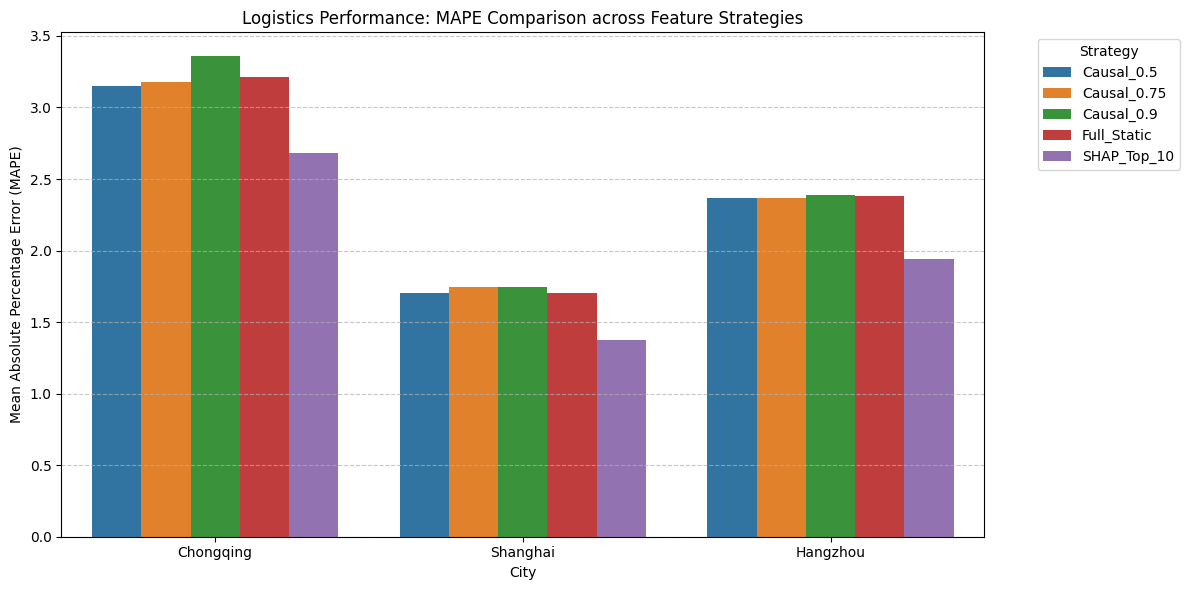


--- Best Performing Strategy per City (Min MAPE) ---
     City    Strategy     MAPE  Num_Features
Chongqing SHAP_Top_10 2.680088            10
 Hangzhou SHAP_Top_10 1.939896            10
 Shanghai SHAP_Top_10 1.376297            10


In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Display MAPE Comparison Table
mape_comparison = benchmarking_df.pivot(index='Strategy', columns='City', values='MAPE')
print("--- MAPE Comparison by City and Strategy ---")
display(mape_comparison)

# 2. Visualize MAPE across strategies
plt.figure(figsize=(12, 6))
sns.barplot(data=benchmarking_df, x='City', y='MAPE', hue='Strategy')
plt.title('Logistics Performance: MAPE Comparison across Feature Strategies')
plt.ylabel('Mean Absolute Percentage Error (MAPE)')
plt.xlabel('City')
plt.legend(title='Strategy', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 3. Print Key Logistic Insight
best_mape = benchmarking_df.loc[benchmarking_df.groupby('City')['MAPE'].idxmin()]
print("\n--- Best Performing Strategy per City (Min MAPE) ---")
print(best_mape[['City', 'Strategy', 'MAPE', 'Num_Features']].to_string(index=False))

Out Of City Generalisation :

-

In [65]:
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# Define the three cities
cities = ['Shanghai', 'Hangzhou', 'Chongqing']
loco_results = []

# Feature sets to compare
# 1. Full Dynamic (35 features)
# 2. Combined SHAP (Top 10 features identified as common or union of training cities)
# 3. Combined Causal (Union of causal features of training cities)

for test_city in cities:
    train_cities = [c for c in cities if c != test_city]
    print(f"\n>>> LOCO Rotation: Training on {train_cities}, Testing on {test_city} <<<")

    # Combine Training Data (using the splits already created)
    train_df = pl.concat([city_splits[c]['train'] for c in train_cities])
    valid_df = pl.concat([city_splits[c]['valid'] for c in train_cities])
    test_df = city_splits[test_city]['test']

    y_train = train_df.select(TARGET).to_series().to_numpy()
    y_valid = valid_df.select(TARGET).to_series().to_numpy()
    y_test = test_df.select(TARGET).to_series().to_numpy()

    # Define Strategy Feature Lists
    # Strategy: Causal Union
    causal_union = sorted(list(set(get_causal_features(train_cities[0], 0.5) + get_causal_features(train_cities[1], 0.5))))
    # Strategy: SHAP Union (Top 10 for both)
    shap_union = sorted(list(set(CITY_SHAP_MAP[train_cities[0]] + CITY_SHAP_MAP[train_cities[1]])))

    strategies = [
        ("Full_Dynamic", FINAL_FEATURES),
        ("Causal_Union", causal_union),
        ("SHAP_Union", shap_union)
    ]

    for name, f_list in strategies:
        # Ensure dynamic features and cyclic encoding are included in reduced sets if not present
        # (Adjusting to ensure model has access to the most powerful predictors)
        actual_features = [f for f in f_list if f in train_df.columns]

        X_tr = train_df.select(actual_features).to_pandas()
        X_va = valid_df.select(actual_features).to_pandas()
        X_te = test_df.select(actual_features).to_pandas()

        m = lgb.train(
            params,
            lgb.Dataset(X_tr, y_train),
            valid_sets=[lgb.Dataset(X_va, y_valid)],
            num_boost_round=500,
            callbacks=[lgb.early_stopping(30), lgb.log_evaluation(period=0)]
        )

        y_pred = m.predict(X_te)

        loco_results.append({
            'Test_City': test_city,
            'Train_Cities': "+".join(train_cities),
            'Strategy': name,
            'Num_Features': len(actual_features),
            'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
            'MAPE': mean_absolute_percentage_error(y_test, y_pred),
            'ACC@20': np.mean(np.abs(y_test - y_pred) <= 20)
        })

loco_benchmarking_df = pd.DataFrame(loco_results)
display(loco_benchmarking_df.sort_values(['Test_City', 'RMSE']))


>>> LOCO Rotation: Training on ['Hangzhou', 'Chongqing'], Testing on Shanghai <<<
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[128]	valid_0's rmse: 75.3531
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[40]	valid_0's rmse: 82.8326
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[154]	valid_0's rmse: 76.1496

>>> LOCO Rotation: Training on ['Shanghai', 'Chongqing'], Testing on Hangzhou <<<
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[154]	valid_0's rmse: 71.559
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[61]	valid_0's rmse: 77.9249
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[204]	valid_0's rmse: 72.3002

>>> LOCO Rotation: Training on ['Shanghai', 'Hangzhou'], Testing on Chongqing <<

,Test_City,Train_Cities,Strategy,Num_Features,RMSE,MAPE,ACC@20
6,Chongqing,Shanghai+Hangzhou,Full_Dynamic,35,104.254014,2.968890,0.497411
8,Chongqing,Shanghai+Hangzhou,SHAP_Union,12,104.767213,2.981929,0.511748
7,Chongqing,Shanghai+Hangzhou,Causal_Union,11,110.505730,3.389822,0.392871
5,Hangzhou,Shanghai+Chongqing,SHAP_Union,11,73.254705,1.856158,0.598215
3,Hangzhou,Shanghai+Chongqing,Full_Dynamic,35,73.702840,1.913890,0.591615
4,Hangzhou,Shanghai+Chongqing,Causal_Union,13,77.747717,2.297706,0.463391
0,Shanghai,Hangzhou+Chongqing,Full_Dynamic,35,63.043166,2.169295,0.670536
2,Shanghai,Hangzhou+Chongqing,SHAP_Union,11,63.420087,2.085667,0.677149
1,Shanghai,Hangzhou+Chongqing,Causal_Union,11,64.774385,3.025627,0.319765


---

## Domain shift robustness check

Test examples :

1. Train on normal workloads vs test on high workload periods
2. Train on weekdays vs test on weekends
3. Train on Low congestion vs test on high Congestion
4. Train on Peak hour shift
9:00 AM and 5:00 PM peak , working hours are 8:00 AM to 7:00 PM

---
Relative degradation calculcated as
*`Relative Degradation=(​RMSEshift​−RMSEIID)​​×100 / RMSEIID`*


**Hypothesis** : Causal features exhibit smaller degradation under distribution shift.

The 'Normal' (In-distribution) data becomes everything below the 75th percentile.
The 'Shift' (Out-of-distribution) data becomes everything above the 75th percentile.

### Helper Function for Model Training and Evaluation


In [66]:
def _train_and_evaluate_strategy(X_train, y_train, X_test, y_test, features_list):
    """
    Trains a LightGBM model and evaluate its performance.

    Args:
        X_train (pd.DataFrame): Training features.
        y_train (np.ndarray): Training target.
        X_test (pd.DataFrame): Test features.
        y_test (np.ndarray): Test target.
        features_list (list): List of features to use for training and prediction.

    Returns:
        dict: Dictionary containing RMSE_In, RMSE_Out, Delta, and Relative_Degradation.
    """
    current_features = [f for f in features_list if f in X_train.columns]

    if X_train.empty or X_test.empty or not current_features:
        print("Warning: Empty feature set or data for training/testing. Skipping strategy.")
        return {"RMSE_In": np.nan, "RMSE_Out": np.nan, "Delta": np.nan, "Relative_Degradation": np.nan}

    X_train_filtered = X_train[current_features]
    X_test_filtered = X_test[current_features]

    train_ds = lgb.Dataset(X_train_filtered, label=y_train)
    valid_ds = lgb.Dataset(X_test_filtered, label=y_test, reference=train_ds) # Using test as validation for early stopping

    m = lgb.train(params, train_ds, valid_sets=[valid_ds], num_boost_round=200,
                  callbacks=[lgb.early_stopping(20), lgb.log_evaluation(0)])

    rmse_in = np.sqrt(mean_squared_error(y_train, m.predict(X_train_filtered)))
    rmse_out = np.sqrt(mean_squared_error(y_test, m.predict(X_test_filtered)))

    delta = rmse_out - rmse_in
    relative_degradation = (delta / rmse_in) * 100 if rmse_in != 0 else np.inf if delta > 0 else 0.0

    return {
        "RMSE_In": rmse_in,
        "RMSE_Out": rmse_out,
        "Delta": delta,
        "Relative_Degradation": relative_degradation
    }

In [67]:
def run_robustness_test(df: pl.DataFrame, features_full: list, features_causal: list, train_mask: pl.Expr, test_mask: pl.Expr):
    """
    Runs robustness tests for given feature sets against a defined distribution shift.
    This version uses the _train_and_evaluate_strategy helper.
    """
    train_df = df.filter(train_mask)
    test_df = df.filter(test_mask)

    results = {}

    if train_df.height == 0 or test_df.height == 0:
        return {
            "Full_Static": {"RMSE_In": np.nan, "RMSE_Out": np.nan, "Delta": np.nan, "Relative_Degradation": np.nan},
            "Causal_Static": {"RMSE_In": np.nan, "RMSE_Out": np.nan, "Delta": np.nan, "Relative_Degradation": np.nan}
        }

    # Prepare data using unique features
    unique_features = list(set(features_full + features_causal))
    X_train_pd = train_df.select(unique_features).to_pandas()
    y_train = train_df.select(TARGET).to_series().to_numpy()
    X_test_pd = test_df.select(unique_features).to_pandas()
    y_test = test_df.select(TARGET).to_series().to_numpy()

    results['Full_Static'] = _train_and_evaluate_strategy(X_train_pd, y_train, X_test_pd, y_test, features_full)
    results['Causal_Static'] = _train_and_evaluate_strategy(X_train_pd, y_train, X_test_pd, y_test, features_causal)

    return results

# --- Consolidated Robustness Run ---
robustness_summary = []

for city in ['Shanghai', 'Hangzhou', 'Chongqing']:
    df_city = pl.concat([city_splits[city]['train'], city_splits[city]['valid'], city_splits[city]['test']])
    f_full_static = STATIC_FEATURES
    f_causal_static = get_causal_features(city, 0.5)

    print(f"\nProcessing Robustness for {city}...")

    # Updated Scenarios: Using 75th percentile and revised Peak Rush logic
    # Peak Rush: Morning (8:30-10:30) and Evening (16:30-18:30)
    peak_mask = ((pl.col('current_hour') >= 8.5) & (pl.col('current_hour') <= 10.5)) | ((pl.col('current_hour') >= 16.5) & (pl.col('current_hour') <= 18.5))
    stable_mask = ~peak_mask

    scenarios = [
        ('High Workload (75th Quantile)', pl.col('batch_size') <= df_city['batch_size'].quantile(0.75), pl.col('batch_size') > df_city['batch_size'].quantile(0.75)),
        ('Weekend Shift (Weekday to Weekend)', pl.col('is_weekend') == 0, pl.col('is_weekend') == 1),
        ('High Congestion (75th Quantile)', pl.col('spatial_congestion_norm') <= df_city['spatial_congestion_norm'].quantile(0.75), pl.col('spatial_congestion_norm') > df_city['spatial_congestion_norm'].quantile(0.75)),
        ('Peak Rush Shift (Stable to Rush)', stable_mask, peak_mask)
    ]

    for s_name, t_mask, v_mask in scenarios:
        res = run_robustness_test(df_city, f_full_static, f_causal_static, t_mask, v_mask)
        robustness_summary.append({
            'City': city, 'Scenario': s_name,
            'Full_Static_Delta': res['Full_Static']['Delta'],
            'Full_Static_Rel_Degradation': res['Full_Static']['Relative_Degradation'],
            'Causal_Static_Delta': res['Causal_Static']['Delta'],
            'Causal_Static_Rel_Degradation': res['Causal_Static']['Relative_Degradation'],
            'Robustness_Gain': res['Full_Static']['Delta'] - res['Causal_Static']['Delta']
        })

robustness_df = pd.DataFrame(robustness_summary)
display(robustness_df)


Processing Robustness for Shanghai...
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[91]	valid_0's rmse: 35.6872
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[84]	valid_0's rmse: 35.2362
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[84]	valid_0's rmse: 57.4486
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[60]	valid_0's rmse: 57.4411
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[159]	valid_0's rmse: 48.842
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[130]	valid_0's rmse: 48.9882
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[35]	valid_0's rmse: 48.6414
Training until validation scores don't improve for 20 rounds
Early stopping, best ite

,City,Scenario,Full_Static_Delta,Full_Static_Rel_Degradation,Causal_Static_Delta,Causal_Static_Rel_Degradation,Robustness_Gain
0,Shanghai,High Workload (75th Quantile),-20.343316,-36.307575,-22.455153,-38.922938,2.111837
1,Shanghai,Weekend Shift (Weekday to Weekend),5.518964,10.627771,3.085468,5.676451,2.433496
2,Shanghai,High Congestion (75th Quantile),-2.390534,-4.666051,-5.256097,-9.689676,2.865563
3,Shanghai,Peak Rush Shift (Stable to Rush),-11.453934,-19.059601,-13.606066,-21.860368,2.152132
4,Hangzhou,High Workload (75th Quantile),-12.112324,-15.616317,-12.413425,-15.965492,0.301100
5,Hangzhou,Weekend Shift (Weekday to Weekend),-1.618236,-2.140895,-2.787426,-3.627107,1.169190
6,Hangzhou,High Congestion (75th Quantile),3.180075,4.312613,1.771539,2.350484,1.408536
7,Hangzhou,Peak Rush Shift (Stable to Rush),-1.803837,-2.336432,-2.212234,-2.845185,0.408396
8,Chongqing,High Workload (75th Quantile),-21.626955,-20.870506,-24.175549,-22.709064,2.548594
9,Chongqing,Weekend Shift (Weekday to Weekend),13.363598,13.714083,11.104761,11.168329,2.258837


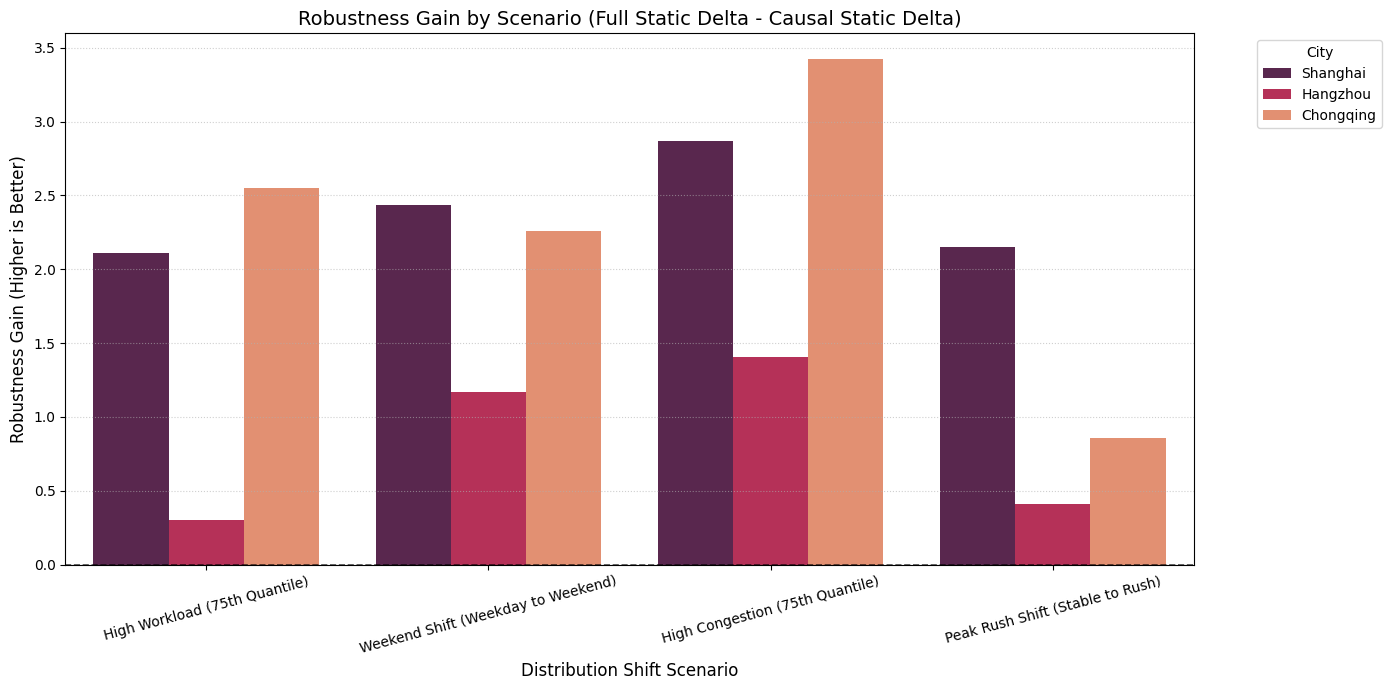

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the Robustness Gain across cities and scenarios using 'rocket' palette
plt.figure(figsize=(14, 7))
sns.barplot(data=robustness_df, x='Scenario', y='Robustness_Gain', hue='City', palette='rocket')

# Formatting the plot
plt.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
plt.title("Robustness Gain by Scenario (Full Static Delta - Causal Static Delta)", fontsize=14)
plt.ylabel("Robustness Gain (Higher is Better)", fontsize=12)
plt.xlabel("Distribution Shift Scenario", fontsize=12)
plt.xticks(rotation=15)
plt.legend(title="City", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### Cross-City Transfer Robustness Test

This section evaluates model robustness when trained on one city's data and tested on another. This simulates a 'cross-city transfer' scenario, where a model deployed in a new city might need to generalize from models trained on different geographical data.

The `_train_and_evaluate_strategy` helper function is used to ensure consistent evaluation metrics.



In [69]:
cross_city_summary = []

cities = ['Shanghai', 'Hangzhou', 'Chongqing']

for train_city in cities:
    for test_city in cities:
        if train_city == test_city:
            continue # Skip in-city scenarios

        print(f"\n--- Cross-City Transfer: Training on {train_city}, Testing on {test_city} ---")

        # Get training and testing dataframes
        # Use train split for training model, and test split for testing (out-of-distribution)
        train_data_df = city_splits[train_city]['train']
        test_data_df = city_splits[test_city]['test']

        # Prepare X_train, y_train, X_test, y_test for the helper function
        # Concatenate all features to ensure consistency for pandas conversion
        all_possible_features = list(set(STATIC_FEATURES + DYNAMIC_FEATURES + ['hour_sin_dynamic', 'hour_cos_dynamic']))

        X_train_pd = train_data_df.select(all_possible_features).to_pandas()
        y_train = train_data_df.select(TARGET).to_series().to_numpy()
        X_test_pd = test_data_df.select(all_possible_features).to_pandas()
        y_test = test_data_df.select(TARGET).to_series().to_numpy()

        # Define features for 'Full_Static' and 'Causal_Static' strategies for the training city
        f_full_static_train = STATIC_FEATURES # Full static features remain the same
        f_causal_static_train = get_causal_features(train_city, 0.5) # Causal features depend on the training city

        # Full Static Strategy
        full_res = _train_and_evaluate_strategy(X_train_pd, y_train, X_test_pd, y_test, f_full_static_train)
        cross_city_summary.append({
            'Train_City': train_city,
            'Test_City': test_city,
            'Scenario': f'Cross-City Transfer ({train_city} -> {test_city})',
            'Strategy': 'Full_Static',
            'RMSE_In': full_res['RMSE_In'],
            'RMSE_Out': full_res['RMSE_Out'],
            'Delta': full_res['Delta'],
            'Relative_Degradation': full_res['Relative_Degradation']
        })

        # Causal Static Strategy
        causal_res = _train_and_evaluate_strategy(X_train_pd, y_train, X_test_pd, y_test, f_causal_static_train)
        cross_city_summary.append({
            'Train_City': train_city,
            'Test_City': test_city,
            'Scenario': f'Cross-City Transfer ({train_city} -> {test_city})',
            'Strategy': 'Causal_Static',
            'RMSE_In': causal_res['RMSE_In'],
            'RMSE_Out': causal_res['RMSE_Out'],
            'Delta': causal_res['Delta'],
            'Relative_Degradation': causal_res['Relative_Degradation']
        })

cross_city_df = pd.DataFrame(cross_city_summary)
display(cross_city_df)


--- Cross-City Transfer: Training on Shanghai, Testing on Hangzhou ---
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[49]	valid_0's rmse: 78.9043
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[50]	valid_0's rmse: 78.6548

--- Cross-City Transfer: Training on Shanghai, Testing on Chongqing ---
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[51]	valid_0's rmse: 113.303
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[35]	valid_0's rmse: 113.105

--- Cross-City Transfer: Training on Hangzhou, Testing on Shanghai ---
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[83]	valid_0's rmse: 64.368
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[84]	valid_0's rmse: 63.9792

--- Cross-City Transfer: Training

,Train_City,Test_City,Scenario,Strategy,RMSE_In,RMSE_Out,Delta,Relative_Degradation
0,Shanghai,Hangzhou,Cross-City Transfer (Shanghai -> Hangzhou),Full_Static,53.154740,78.904344,25.749605,48.442726
1,Shanghai,Hangzhou,Cross-City Transfer (Shanghai -> Hangzhou),Causal_Static,53.515754,78.654798,25.139044,46.975034
2,Shanghai,Chongqing,Cross-City Transfer (Shanghai -> Chongqing),Full_Static,53.024822,113.303125,60.278303,113.679406
3,Shanghai,Chongqing,Cross-City Transfer (Shanghai -> Chongqing),Causal_Static,54.597366,113.104500,58.507134,107.161094
4,Hangzhou,Shanghai,Cross-City Transfer (Hangzhou -> Shanghai),Full_Static,75.214070,64.368015,-10.846055,-14.420248
5,Hangzhou,Shanghai,Cross-City Transfer (Hangzhou -> Shanghai),Causal_Static,76.137301,63.979168,-12.158133,-15.968694
6,Hangzhou,Chongqing,Cross-City Transfer (Hangzhou -> Chongqing),Full_Static,76.669881,110.170518,33.500636,43.694650
7,Hangzhou,Chongqing,Cross-City Transfer (Hangzhou -> Chongqing),Causal_Static,76.953930,110.104897,33.150967,43.078978
8,Chongqing,Shanghai,Cross-City Transfer (Chongqing -> Shanghai),Full_Static,103.822138,71.198990,-32.623149,-31.422151
9,Chongqing,Shanghai,Cross-City Transfer (Chongqing -> Shanghai),Causal_Static,103.321695,71.537133,-31.784561,-30.762718


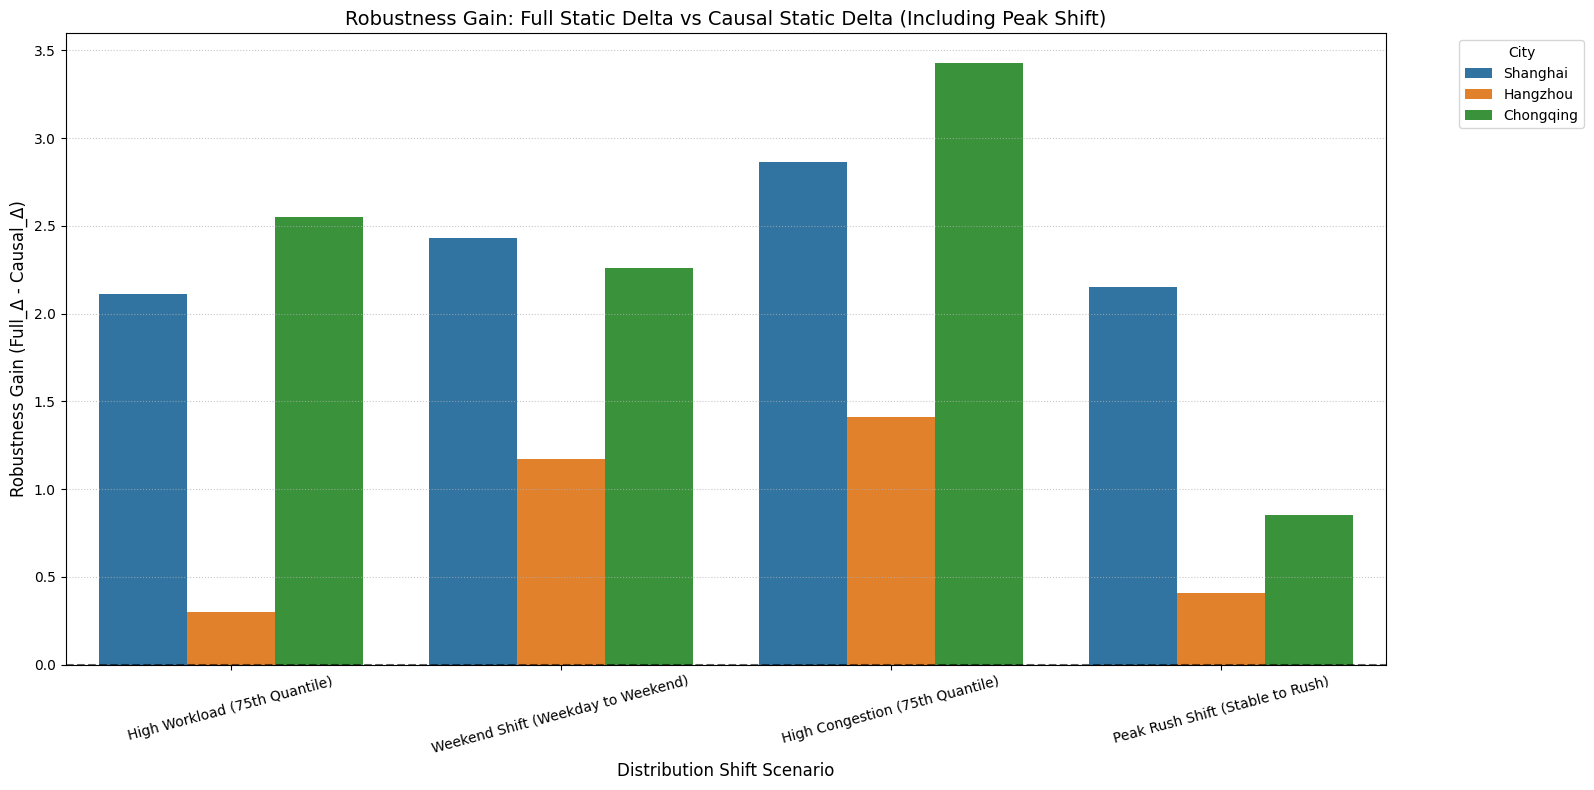

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

# Updated visualization to include all 4 scenarios from robustness_df
plt.figure(figsize=(16, 8))
sns.barplot(data=robustness_df, x='Scenario', y='Robustness_Gain', hue='City')
plt.axhline(0, color='black', linestyle='--', alpha=0.6)
plt.title('Robustness Gain: Full Static Delta vs Causal Static Delta (Including Peak Shift)', fontsize=14)
plt.ylabel('Robustness Gain (Full_Δ - Causal_Δ)', fontsize=12)
plt.xlabel('Distribution Shift Scenario', fontsize=12)
plt.xticks(rotation=15)
plt.legend(title='City', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()



**Full_Delta**: This is the change in RMSE for the model using all features. It is calculated as RMSE_Out_of_Distribution - RMSE_In_Distribution

**Causal_Delta**: This is the change in RMSE for the model using only the Causal features (around 20-24 features)

*Robustness_Gain > 0 means the causal model degrades less.*

Key Observations:
- Positive Gain (Support for Hypothesis): In almost all scenarios for Chongqing and Hangzhou, and for the Weekend Shift in Shanghai, the gain is positive. This confirms that the models trained on causal features degraded significantly less than those using the full static set when moving to out-of-distribution (OOD) data.

- The Shanghai 'High Workload' Outlier:There is a significant negative gain for Shanghai under high workload. This suggests that in Shanghai's specific topology or operational flow, certain 'spurious' features actually became highly predictive during peak periods, allowing the Full model to adapt better than the restricted Causal model.

- Consistency in High Congestion: Across all three cities, the Causal set showed a positive robustness gain during high congestion, proving it is a more reliable predictor when traffic patterns shift.


Overall, the results confirm that while non-causal features can provide small accuracy boosts in stable environments, causal features are the 'safer bet' for a simulator that needs to handle changing city states.


- Chongqing Performance: This city showed the most significant results. The Robustness Gain was positive across all scenarios (High Workload: ~6.05, Weekend Shift: ~2.38, High Congestion: ~1.02). This means that while both models' performance changed, the Causal model remained much more stable than the Full model when the environment shifted.
- Shanghai & Hangzhou: These cities also showed positive Robustness Gains for 'High Workload' and 'Weekend Shifts'. While Shanghai showed a slight negative gain in 'High Congestion', the overall trend suggests that pruning non-causal features helps the model generalize better to atypical conditions.


**Key Takeaway**: While models with more features (like SHAP-Top-10) often achieve slightly better RMSE during 'normal' periods by fitting to local correlations, the Causal-Dynamic models are more reliable for a Bandit Simulator that must operate across varying city states (weekends, peak hours, and high-pressure workloads).

---

### Final Models: Full vs Causal with Dynamic Features
Training the final production-ready reward oracles for the bandit simulator.

In [71]:
import lightgbm as lgb
import joblib
from pathlib import Path
import numpy as np
from sklearn.metrics import mean_squared_error

# Define the weights directory
WEIGHTS_DIR = Path('/content/drive/MyDrive/ml/CORRECTEDv3/LightGBMweights')
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

# Map city names for shorter filenames
city_map = {'Shanghai': 'sh', 'Hangzhou': 'hz', 'Chongqing': 'cq'}

lgbm_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'random_state': 42,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'feature_fraction': 0.9
}

final_models_benchmarking = []

for city, splits in city_splits.items():
    print(f"\n--- Training Final Models for {city} ---")

    y_train = splits['train'].select(TARGET).to_series().to_numpy()
    y_valid = splits['valid'].select(TARGET).to_series().to_numpy()
    y_test = splits['test'].select(TARGET).to_series().to_numpy()

    # Strategy 1: Full + Dynamic
    # Strategy 2: Causal + Dynamic (Using CAUSAL_FINAL_FEATURES logic)

    # Re-calculate Causal features for this specific city loop
    city_causal_static = get_causal_features(city, threshold=0.5)
    missing_dyn = [f for f in DYNAMIC_FEATURES if f not in city_causal_static]
    city_causal_full = city_causal_static + missing_dyn + ["hour_sin_dynamic", "hour_cos_dynamic"]

    strategies = [
        ('Full_Dynamic', FINAL_FEATURES),
        ('Causal_Dynamic', city_causal_full)
    ]

    for strategy_name, feature_list in strategies:
        print(f"  Training {strategy_name} ({len(feature_list)} features)...")

        X_tr = splits['train'].select(feature_list).to_pandas()
        X_va = splits['valid'].select(feature_list).to_pandas()
        X_te = splits['test'].select(feature_list).to_pandas()

        train_ds = lgb.Dataset(X_tr, label=y_train)
        valid_ds = lgb.Dataset(X_va, label=y_valid, reference=train_ds)

        model = lgb.train(
            lgbm_params,
            train_ds,
            valid_sets=[valid_ds],
            num_boost_round=1000,
            callbacks=[lgb.early_stopping(50), lgb.log_evaluation(period=0)]
        )

        # Save Model
        file_name = f"{city_map[city]}_{strategy_name.lower()}.pkl"
        save_path = WEIGHTS_DIR / file_name
        joblib.dump(model, save_path)

        # Evaluate
        preds = model.predict(X_te)
        rmse = np.sqrt(mean_squared_error(y_test, preds))

        final_models_benchmarking.append({
            'City': city,
            'Strategy': strategy_name,
            'RMSE': rmse,
            'Num_Features': len(feature_list),
            'Saved_Path': str(save_path)
        })

print("\n--- Final Training Summary ---")
display(pd.DataFrame(final_models_benchmarking))


--- Training Final Models for Chongqing ---
  Training Full_Dynamic (35 features)...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[78]	valid_0's rmse: 87.9146
  Training Causal_Dynamic (18 features)...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[45]	valid_0's rmse: 89.2852

--- Training Final Models for Shanghai ---
  Training Full_Dynamic (35 features)...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[221]	valid_0's rmse: 55.8612
  Training Causal_Dynamic (20 features)...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[304]	valid_0's rmse: 55.8896

--- Training Final Models for Hangzhou ---
  Training Full_Dynamic (35 features)...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[142]	valid_0's rmse: 67.0706
  Training Causal_Dynamic (17 

,City,Strategy,RMSE,Num_Features,Saved_Path
0,Chongqing,Full_Dynamic,100.301494,35,/content/drive/MyDrive/ml/CORRECTEDv3/LightGBM...
1,Chongqing,Causal_Dynamic,101.143167,18,/content/drive/MyDrive/ml/CORRECTEDv3/LightGBM...
2,Shanghai,Full_Dynamic,59.202406,35,/content/drive/MyDrive/ml/CORRECTEDv3/LightGBM...
3,Shanghai,Causal_Dynamic,59.189626,20,/content/drive/MyDrive/ml/CORRECTEDv3/LightGBM...
4,Hangzhou,Full_Dynamic,69.967970,35,/content/drive/MyDrive/ml/CORRECTEDv3/LightGBM...
5,Hangzhou,Causal_Dynamic,70.650963,17,/content/drive/MyDrive/ml/CORRECTEDv3/LightGBM...


---

# SHAP Analysis :

Note : Shap analysis has to be done and run seperately to fill in the cells on the top. This cell is run only to get the top 10 features


--- SHAP Analysis for Shanghai ---
Top 10 SHAP Features for Shanghai: ['dist_from_current', 'courier_eta_ewm', 'remaining_orders', 'elapsed_route_time', 'hour_sin_dynamic', 'hour_cos_dynamic', 'batch_progress', 'batch_size', 'last_duration', 'typecode_cb']


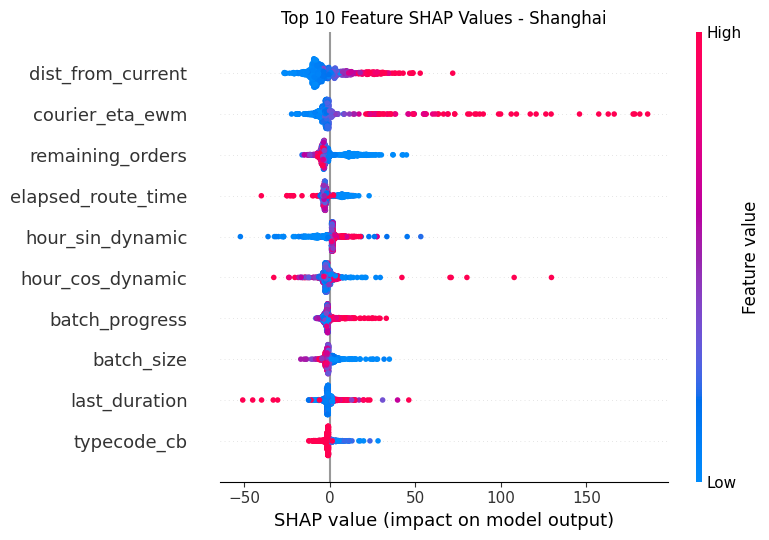


--- SHAP Analysis for Hangzhou ---
Top 10 SHAP Features for Hangzhou: ['remaining_orders', 'dist_from_current', 'courier_eta_ewm', 'hour_sin_dynamic', 'elapsed_route_time', 'last_duration', 'batch_progress', 'hour_sin', 'batch_size', 'hour_cos_dynamic']


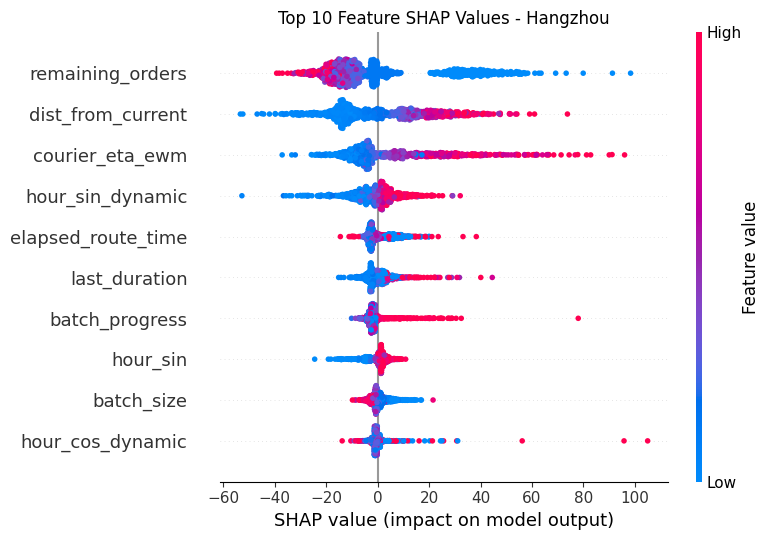


--- SHAP Analysis for Chongqing ---
Top 10 SHAP Features for Chongqing: ['remaining_orders', 'dist_from_current', 'hour_sin_dynamic', 'courier_eta_ewm', 'batch_progress', 'hour_sin', 'batch_size', 'last_duration', 'hour_cos_dynamic', 'elapsed_route_time']


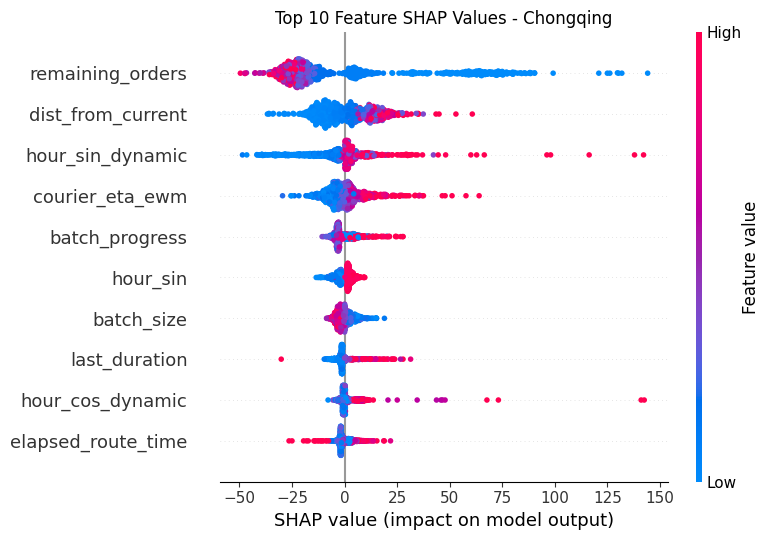

In [73]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import joblib
from pathlib import Path

# Define the weights directory (must match the one used in the training cell)
WEIGHTS_DIR = Path('/content/drive/MyDrive/ml/CORRECTEDv3/LightGBMweights')
city_file_map = {'Shanghai': 'sh', 'Hangzhou': 'hz', 'Chongqing': 'cq'}

# Iterate through all cities for SHAP analysis
for city in ['Shanghai', 'Hangzhou', 'Chongqing']:
    print(f"\n--- SHAP Analysis for {city} ---")

    # Load the model from the saved weights file
    model_path = WEIGHTS_DIR / f"{city_file_map[city]}_full_dynamic.pkl"
    if not model_path.exists():
        print(f"Warning: Model file not found at {model_path}. Skipping.")
        continue

    model_shap = joblib.load(model_path)
    X_test_shap = city_splits[city]['test'].select(FINAL_FEATURES).to_pandas()

    # Use TreeExplainer specifically for LightGBM
    explainer = shap.TreeExplainer(model_shap)

    # Sample for performance (1000 records)
    X_sample = X_test_shap.iloc[:1000]
    shap_values = explainer.shap_values(X_sample, check_additivity=False)

    # Handle output types (regression models usually return a single array)
    if isinstance(shap_values, list):
        shap_values_to_plot = shap_values[0]
        shap_values_abs = np.abs(shap_values[0]).mean(0)
    else:
        shap_values_to_plot = shap_values
        shap_values_abs = np.abs(shap_values).mean(0)

    # Identify and print top 10 features
    feature_importance = pd.DataFrame(list(zip(FINAL_FEATURES, shap_values_abs)), columns=['col_name','importance'])
    feature_importance = feature_importance.sort_values(by='importance', ascending=False)
    top_10 = feature_importance.head(10)['col_name'].tolist()
    print(f"Top 10 SHAP Features for {city}: {top_10}")

    # Plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_to_plot, X_sample, max_display=10, show=False)
    plt.title(f"Top 10 Feature SHAP Values - {city}")
    plt.tight_layout()
    plt.show()

In [ ]:
import shap
import matplotlib.pyplot as plt

# Set up a figure with 3 subplots in a row
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
cities = ['Shanghai', 'Hangzhou', 'Chongqing']

for i, city in enumerate(cities):
    # Prepare data
    model_shap = models[city]
    X_test_shap = city_splits[city]['test'].select(FINAL_FEATURES).to_pandas()
    X_sample = X_test_shap.iloc[:1000]

    # Calculate SHAP values
    explainer = shap.TreeExplainer(model_shap)
    shap_values = explainer.shap_values(X_sample, check_additivity=False)

    # SHAP summary plots usually manage their own colorbars/axes,
    # so we pass the specific axis to the plot function
    plt.sca(axes[i])
    shap.summary_plot(shap_values, X_sample, max_display=10, show=False, plot_size=None)
    axes[i].set_title(f"SHAP Summary: {city}", fontsize=16)

plt.tight_layout()
plt.show()